# Image Similarity Analysis: Using the CLIP Embedder, SSIM and PSNR

Welcome to the guide on using the `ClipEmbedder`, `SSIM` and `PSNR` for image similarity analysis. Here, we will walk through the following steps:

1. Initializing a `ClipEmbedder` with pre-trained weights.
2. Embedding images and computing similarities.
3. Creating a compressed and a noised version of an image.
4. Comparing the image with both versions using `SSIM` and `PSNR`.

## 1. Setting Up

Let's begin by importing the necessary modules and preparing our environment.

### Required Imports and Configuration

In [1]:
import io
from itertools import islice

import numpy as np
from PIL import Image

from pyvisim_examples.utils import plot_image
from pyvisim.datasets import OxfordFlowerDataset
from pyvisim.neural_networks import ClipEmbedder
from pyvisim.pixelwise import PSNR
from pyvisim.structural import SSIM

### Set the strength of the image degradations

`JPEG_QUALITY` is the JPEG quality (from 1 to 95) of the compressed image, and `NOISE_SIGMA` is the standard deviation of the Gaussian noise added to the noised image. Lower the quality or raise the noise to degrade the image further.

In [2]:
JPEG_QUALITY = 10
NOISE_SIGMA = 25

## 2. Initializing the CLIP Embedder

The `ClipEmbedder` downloads the pre-trained weights of the requested CLIP variant from the Hugging Face Hub on first use and caches them. Here, we use the `ViT-B-32` variant with the original `openai` weights.

Unlike the VLAD and Fisher Vector embedders, the `ClipEmbedder` is already trained, so there is no need to call a `learn` method.

In [3]:
# Initialize a CLIP embedder
clip_embedder = ClipEmbedder(variant="ViT-B-32", pretrained="openai")
print("CLIP embedder:", clip_embedder)

CLIP embedder: ClipEmbedder(variant=ViT-B-32, pretrained=openai, device=cuda, normalize=True, similarity_func=cosine)


## 3. Embedding Images and Computing Similarities

First, we load some sample images from the Oxford Flower dataset.

In [4]:
# Load sample images from the Oxford Flower dataset
dataset = OxfordFlowerDataset()
images = [
    image for i, (image, *_) in enumerate(islice(dataset, 200))
]  # Set '200' to len(dataset) for full dataset

### Example: Embedding Images

We will convert all images from the dataset batch above to embeddings (which is basically the numerical representation of the image using the algorithm of the embedder).

In [5]:
image_embeddings_clip = clip_embedder.embed(images)
print("Shape of CLIP embeddings:", image_embeddings_clip.shape)

Shape of CLIP embeddings: (200, 512)



### Example: Computing Similarity Between Two Images

First, we choose and plot the images to compare.

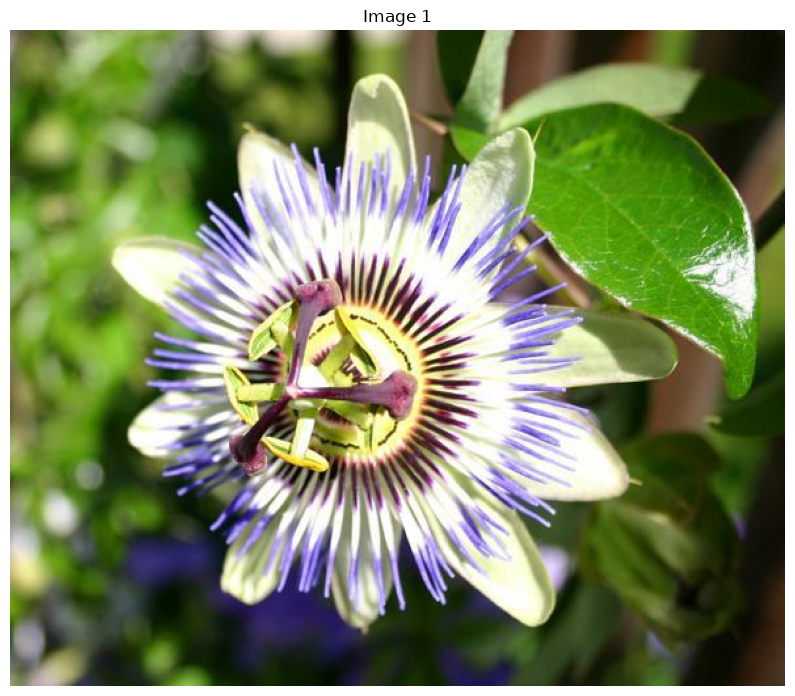

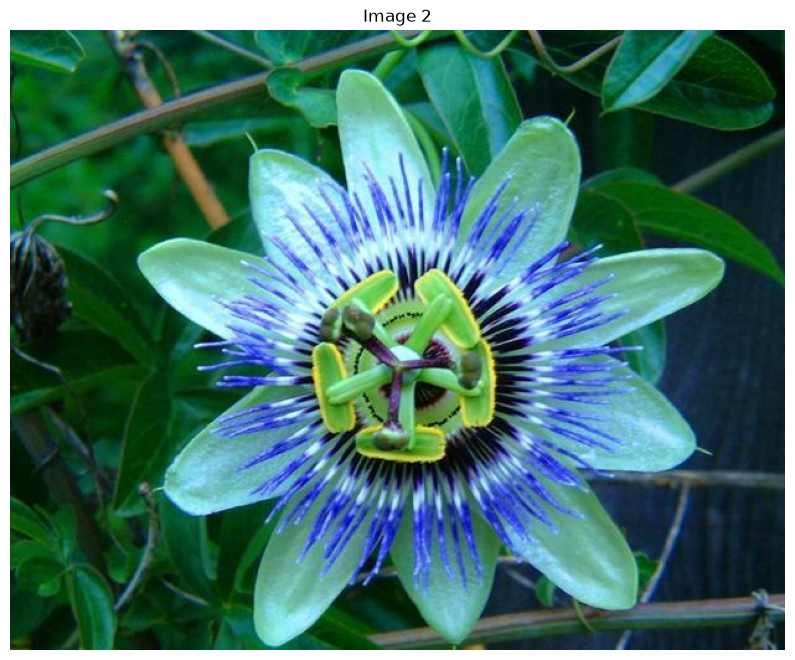

In [6]:
image_1, image_2 = images[0], images[1]
plot_image(image_1, title="Image 1")
plot_image(image_2, title="Image 2")

In [7]:
# Compute similarity using the CLIP embedder
similarity = clip_embedder.similarity_score(image_1, image_2)

print("Similarity score:", similarity)

Similarity score: [[0.93113333]]


## 4. Comparing an Image with its Compressed and Noised Versions

`SSIM` and `PSNR` do not embed the images. Instead, they compare two aligned images pixel by pixel, so both images must have the same shape:

- `SSIM` compares local luminance, contrast and structure statistics. Identical images score `1`, and the score drops as the structure of the image is lost.
- `PSNR` measures the pixel-wise error in decibels. Higher means more similar, and identical images score `inf`.

Hence, they are well suited to measure how much an image was degraded, e.g. by compression or noise. Note that `image_1` and `image_2` above cannot be compared this way, since their shapes differ.

### Example: Creating a Compressed and a Noised Image

We create a JPEG-compressed and a noised version of `image_1`.

In [8]:
def compress_jpeg(image, quality):
    """
    Compress an image with JPEG and decode it again.

    :param image: RGB image as a NumPy array (H, W, C)
    :param quality: JPEG quality, from 1 to 95
    :return: The decoded JPEG image as a NumPy array (H, W, C)
    """
    buffer = io.BytesIO()
    Image.fromarray(image).save(buffer, format="JPEG", quality=quality)
    with Image.open(buffer) as compressed:
        return np.asarray(compressed.convert("RGB"))


def add_gaussian_noise(image, sigma, seed=42):
    """
    Add Gaussian noise to an image.

    :param image: RGB image as a NumPy array (H, W, C)
    :param sigma: Standard deviation of the noise, in pixel values
    :param seed: Seed of the random number generator
    :return: The noised image as a NumPy array (H, W, C)
    """
    rng = np.random.default_rng(seed)
    noise = rng.normal(0.0, sigma, size=image.shape)
    return np.clip(image + noise, 0, 255).astype(np.uint8)

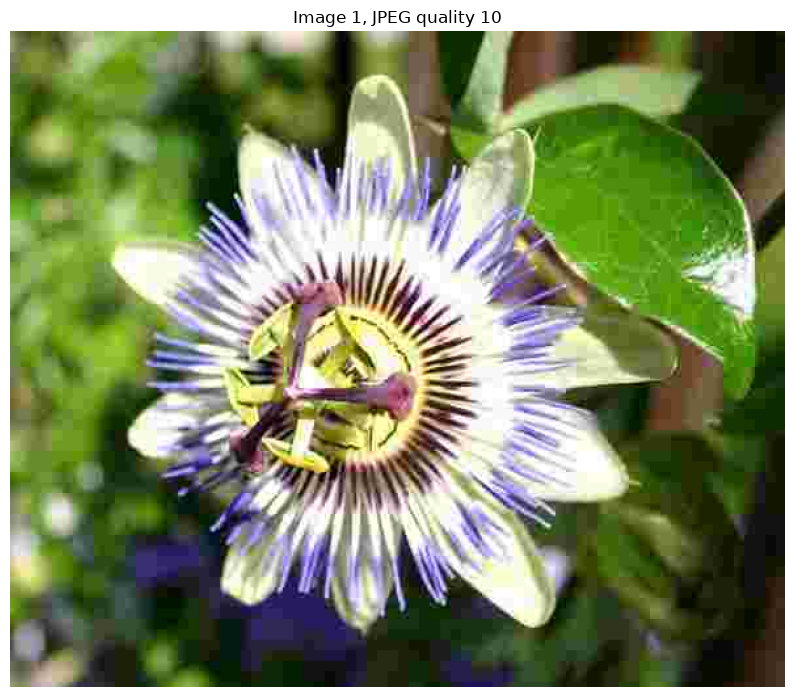

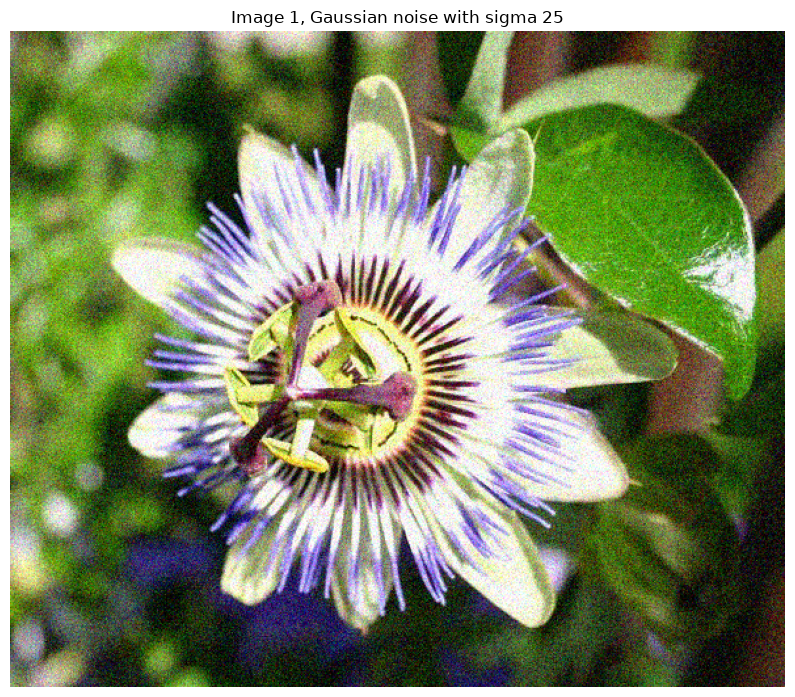

In [9]:
compressed_image = compress_jpeg(image_1, JPEG_QUALITY)
noised_image = add_gaussian_noise(image_1, NOISE_SIGMA)
plot_image(compressed_image, title=f"Image 1, JPEG quality {JPEG_QUALITY}")
plot_image(noised_image, title=f"Image 1, Gaussian noise with sigma {NOISE_SIGMA}")

### Example: Computing SSIM and PSNR

Now, we compare `image_1` with its compressed and its noised version.

In [10]:
# Compute similarity using SSIM
ssim = SSIM()

print("SSIM, compressed image:", ssim.similarity_score(image_1, compressed_image))
print("SSIM, noised image:", ssim.similarity_score(image_1, noised_image))

SSIM, compressed image: [[0.80544227]]
SSIM, noised image: [[0.37555055]]


In [11]:
# Compute similarity using PSNR
psnr = PSNR()

print("PSNR, compressed image:", psnr.similarity_score(image_1, compressed_image))
print("PSNR, noised image:", psnr.similarity_score(image_1, noised_image))

PSNR, compressed image: [[26.45586812]]
PSNR, noised image: [[20.84264716]]
